# Electrical System Modeling Example

**Learning Goals**
- Derive transfer functions for series and parallel RL circuits

## Relevant lecture videos

In [7]:
from IPython.display import HTML

HTML('<iframe width="560" height="315" src="https://echo360.org/media/4e0d7716-4020-49a6-ad88-103d80b6d6e8/public?autoplay=false&automute=false&currentMediaId=da79b8b6-35c0-45c1-a423-7f129fe2f50b" frameborder="0" allowfullscreen></iframe>')

In [8]:
from IPython.display import HTML

HTML('<iframe width="560" height="315" src="https://echo360.org/media/e1b23832-c1c1-4726-9b52-5dedb68f7332/public?autoplay=false&automute=false&currentMediaId=0ab064c2-882f-45b3-bca3-3685e136ad12" frameborder="0" allowfullscreen></iframe>')

In [9]:
from IPython.display import HTML

HTML('<iframe width="560" height="315" src="https://echo360.org/media/6323e063-b99e-4f78-aa6e-2ec13950ad0c/public?autoplay=false&automute=false&currentMediaId=1f9e6e6d-e389-45d0-b835-f1c51dd3418b" frameborder="0" allowfullscreen></iframe>')

In [10]:
from IPython.display import HTML

HTML('<iframe width="560" height="315" src="https://echo360.org/media/da85b0a5-1188-41c8-897f-57cd382ade46/public?autoplay=false&automute=false&currentMediaId=0021a8db-aa22-4c8b-bea0-2b6d698bbf12" frameborder="0" allowfullscreen></iframe>')

In [12]:
from IPython.display import HTML

HTML('<iframe width="560" height="315" src="https://echo360.org/media/7fe7df55-2f6f-4638-b95c-4fbd205eef14/public?autoplay=false&automute=false&currentMediaId=31af1fa7-adf2-4d87-8f9c-31bb5fc7b3b2" frameborder="0" allowfullscreen></iframe>')

In [1]:
%pip install -q ipywidgets schemdraw

Note: you may need to restart the kernel to use updated packages.


In [2]:
import schemdraw
import schemdraw.elements as elm
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded.")

Libraries loaded.


---
## Series RL Circuit (Voltage Divider)

A resistor $R$ and inductor $L$ in series, driven by a voltage source $V_{\text{in}}$.
Output is the voltage across the inductor $V_L$.

**Voltage divider formula with current i(t) as a function of time:**

$$V_{in} = V_R + V_L = i(t)R + L\frac{d i(t)}{d t}$$

Perform Laplace transform assuming zero initial condition:

$$V_{in} = I(s)R +  sI(s)L - I(0) = I(s)R + sI(s)L = I(s)(R+sL)$$

Therefore,

$$V_L = V_{\text{in}} \cdot \frac{Ls}{R + Ls}$$

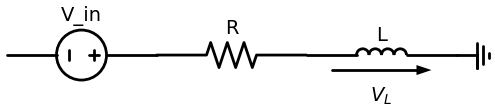

In [3]:
with schemdraw.Drawing() as d:
    elm.SourceV().label('V_in').right()
    elm.Resistor().label('R').right()
    L = elm.Inductor().label('L').right()
    elm.CurrentLabel(top=False, ofst=.3).at(L).label('$V_L$')
    elm.Ground().up()

**Transfer function:**
$$H(s) = \frac{V_L(s)}{V_{\text{in}}(s)} = \frac{Ls}{R + Ls} = \frac{s}{s + R/L}$$

This is a **first-order high-pass filter**:
- **DC ($s \to 0$):** gain $\to 0$ (inductor = short circuit)
- **High frequency $\omega$:** gain $\to 1$ (inductor = open circuit)
- **Pole:** $s = -R/L$

In [4]:
R_s = widgets.FloatSlider(min=1, max=100, step=1, value=10,
                          description='R (\u03A9):',
                          style={'description_width': 'initial'})
L_s = widgets.FloatSlider(min=0.1, max=10, step=0.1, value=1,
                          description='L (H):',
                          style={'description_width': 'initial'})
out_s = widgets.Output()

def plot_step_response(R, L):
    tau = L / R
    t = np.linspace(0, 5 * tau, 500)
    v_L = np.exp(-t / tau)
    
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(t, v_L, 'b-', linewidth=2)
    ax.axvline(tau, color='r', linestyle=':', alpha=0.5,
               label=f'$\\tau = L/R = {tau:.3f}$ s')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('$V_L$ (V)')
    ax.set_title('Series RL: Step Response $V_L(t)$')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.show()

def update_s(b=None):
    with out_s:
        clear_output(wait=True)
        plot_step_response(R_s.value, L_s.value)

R_s.observe(update_s, 'value')
L_s.observe(update_s, 'value')
update_s()
display(widgets.VBox([R_s, L_s, out_s]))

---
## Summary

| Circuit | Configuration | Transfer Function | Filter Type | Corner |
|---------|---------------|-------------------|-------------|--------|
| Series RL | Voltage divider: $V_L/V_{\text{in}}$ | $\dfrac{Ls}{R + Ls}$ | High-pass | $\omega_c = R/L$ |

Pole $s = -R/L$ and corner frequency $\omega_c = R/L$.